In [1]:
# Install Dependencies
!pip install ultralytics
!pip install opencv2
!apt-get install -y p7zip-full

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.1 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement opencv2 (from versions: none)
ERROR: No matching distribution found for opencv2
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [2]:
# Dataset zip download from Google Drive
!gdown --id 1AAqko9b0uxQe2jP_DNk1lDylCphRHKQo

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1AAqko9b0uxQe2jP_DNk1lDylCphRHKQo
From (redirected): https://drive.google.com/uc?id=1AAqko9b0uxQe2jP_DNk1lDylCphRHKQo&confirm=t&uuid=99175138-79b2-44cc-aa02-aa7073cd02e3
To: /content/Dataset_Merged.7z
100% 2.19G/2.19G [00:29<00:00, 73.8MB/s]


In [3]:
# Dataset unpacking to runtime
!7z x /content/Dataset_Merged.7z -o/content/dataset/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 2193739363 bytes (2093 MiB)

Extracting archive: /content/Dataset_Merged.7z
--
Path = /content/Dataset_Merged.7z
Type = 7z
Physical Size = 2193739363
Headers Size = 1445192
Method = LZMA2:25
Solid = +
Blocks = 1

  0%      0% 10         0% 63 - Dataset_Merged/test/images/d_fire_AoF04496.jpg                                                          0% 124 - Dataset_Merged/test/images/d_fire_AoF05056.jpg                                                         

In [9]:
# Importing Libraries
from google.colab import drive
drive.mount('/content/drive')

import os
from ultralytics import YOLO
import yaml
import glob
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train Images: 24108
Validate Images: 6812
Test Images: 3399
------------------------------------------------
Total Label Files: 24108
Classes: ['Fire', 'Smoke']
------------------------------------------------
Fire Annotations: 29479
Smoke Annotations: 14617
Fire-Smoke Ratio: 2.017:1


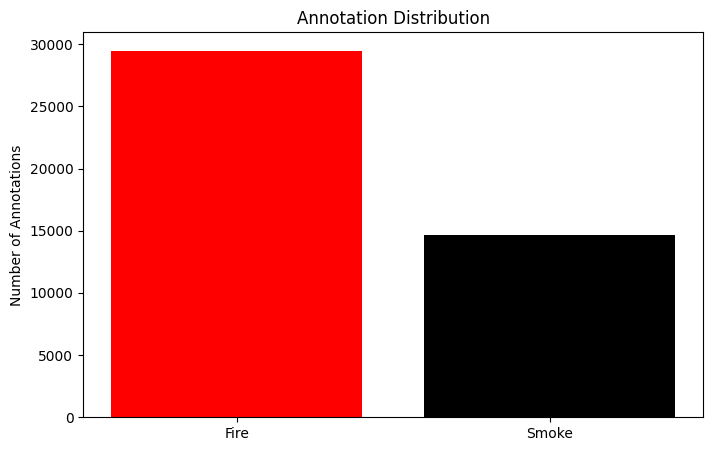

In [ ]:
# Dataset verification

dataset = "/content/dataset/Dataset_Merged"
dataset_yaml = "/content/dataset/Dataset_Merged/data.yaml"
database_train_label = "/content/dataset/Dataset_Merged/train/labels"

# 1. Check the number of images on each subfolders
def count_files(subfolders):
    path = os.path.join(dataset, subfolders, "images")
    files = os.listdir(path)
    return len(files)

train_count = count_files("train")
val_count = count_files("val")
test_count = count_files("test")

# 2. Open yaml and read the classes
with open(dataset_yaml) as file:
    data = yaml.safe_load(file)
    classes = data["names"]

# 3. How many fire and smokes in training phase?

files = os.listdir(database_train_label)
fire_count = 0
smoke_count = 0

for file_name in files:
    file_path = os.path.join(database_train_label, file_name)

    with open(file_path, "r") as file:
        lines = file.readlines()

        for line in lines:
            parts = line.split()
            class_id = parts[0]

            if class_id == "0":
                fire_count += 1
            elif class_id == "1":
                smoke_count += 1

# 4. Visualize the annotations in a histogram/bar chart
classes = ['Fire', 'Smoke']
counts = [fire_count, smoke_count]

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['red', 'black'])
plt.title('Annotation Distribution')
plt.ylabel('Number of Annotations')


print("Train Images:", train_count)
print("Validate Images:", val_count)
print("Test Images:", test_count)
print("------------------------------------------------")
print(f"Total Label Files: {len(files)}")
print(f"Classes: {classes}")
print("------------------------------------------------")
print(f"Fire Annotations: {fire_count}")
print(f"Smoke Annotations: {smoke_count}")
print(f"Fire-Smoke Ratio: {fire_count/smoke_count:.3f}:1")
plt.show()


# Yolov8s Model training part 1

Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      8.93G      1.714      2.042      1.648         23        736: 100% ━━━━━━━━━━━━ 754/754 1.0it/s 12:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:15
                   all       6812      12529      0.549      0.485      0.481      0.221

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      8.58G      1.663      1.602      1.585         28        736: 100% ━━━━━━━━━━━━ 754/754 1.0it/s 12:02
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.3it/s 1:21
                   all       6812      12529      0.524      0.436      0.425      0.197

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      8.97G      1.741      1.728      1.644         33        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:11
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.501      0.419      0.404       0.17

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      9.03G      1.774      1.802      1.686         28        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529       0.58      0.484      0.506      0.234

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/100      9.07G      1.703      1.659      1.639         40        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:06
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:13
                   all       6812      12529      0.647      0.537      0.587      0.288

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/100       9.1G      1.648      1.549      1.594         21        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:14
                   all       6812      12529      0.672      0.553      0.618      0.308

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/100       9.1G      1.615      1.483      1.567         23        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.697      0.595      0.657      0.333

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/100      9.02G      1.592      1.437      1.544         18        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:14
                   all       6812      12529      0.703      0.582      0.654      0.337

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/100      9.08G       1.57      1.391      1.531         17        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.728      0.619      0.696      0.364

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/100      9.05G      1.552      1.355      1.518         24        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:10
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:14
                   all       6812      12529      0.732      0.621      0.701      0.368

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/100         9G      1.529      1.322      1.498         32        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:13
                   all       6812      12529      0.758      0.623      0.711      0.383

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/100      9.09G      1.519      1.306      1.491         33        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:13
                   all       6812      12529      0.738       0.64       0.72      0.388

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/100      9.02G      1.507      1.272      1.473         36        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:07
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:14
                   all       6812      12529      0.753      0.651      0.731      0.398

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/100      8.97G        1.5      1.254      1.469         33        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:13
                   all       6812      12529      0.761      0.661      0.743      0.406

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/100      9.05G      1.481      1.234      1.456         36        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:02
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:13
                   all       6812      12529       0.76      0.669      0.748      0.416

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/100      8.98G      1.473      1.212       1.45         53        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:01
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:15
                   all       6812      12529      0.771      0.672      0.753      0.418

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/100      9.04G      1.461      1.195      1.437         21        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:16
                   all       6812      12529       0.79      0.673      0.765       0.43

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/100      9.11G       1.45      1.186      1.433         22        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:20
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.792       0.68      0.769      0.434

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/100      9.06G      1.445      1.168      1.432         28        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:20
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.788      0.688      0.773      0.438

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/100      8.97G      1.437      1.153      1.422         26        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:14
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:15
                   all       6812      12529      0.784      0.689      0.775      0.441

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/100      9.05G      1.432       1.14      1.418         30        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:14
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529       0.79        0.7      0.783      0.447

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/100      9.04G      1.418      1.126      1.406         32        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 11:06
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529      0.793      0.707      0.786      0.449

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/100      9.03G      1.414      1.119      1.403         41        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 10:58
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.4it/s 1:14
                   all       6812      12529        0.8      0.706       0.79      0.454

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/100       8.6G      1.403      1.095       1.39         27        736: 100% ━━━━━━━━━━━━ 754/754 1.1it/s 10:56
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 1.5it/s 1:11
                   all       6812      12529      0.793      0.716      0.794      0.458

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/100      9.07G        1.4      1.092      1.357        105        736: 1% ──────────── 5/754 1.1it/s 4.8s<11:25
    

In [ ]:
# Yolov8s Model training part 2

DATA    = "/content/dataset/Dataset_Merged/data.yaml"
SAVE    = "/content/drive/MyDrive/Project/Model_Yolov8s"
WEIGHTS = f"{SAVE}/fire_v2/weights/last.pt"

model = YOLO(WEIGHTS)

model.train(data=DATA,epochs=100,imgsz=736,batch=32,amp=True,workers=4,patience=20,
            save=True,save_period=5,plots=True,project=SAVE,name="fire_v2",exist_ok=True,
            resume = True)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/final_merged_3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False

In [ ]:
# Yolov8n Model training part 1

DATA    = "/content/dataset/Dataset_Merged/data.yaml"
SAVE    = "/content/drive/MyDrive/Project/Model_Yolov8n"
WEIGHTS = f"{SAVE}/fire_v2/weights/last.pt"

model = YOLO(WEIGHTS) if os.path.exists(WEIGHTS) else YOLO("yolov8n.pt")

model.train(data=DATA,epochs=45,imgsz=736,batch=32,amp=True,workers=4,patience=20,
            save=True,save_period=5,plots=True,project=SAVE,name="fire_v2",exist_ok=True,
            resume = True)

WARNING ⚠️ model 'yolov8n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/final_merged_3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300

In [ ]:
# Yolov8n Model training part 2

DATA    = "/content/dataset/Dataset_Merged/data.yaml"
SAVE    = "/content/drive/MyDrive/Project/Model_Yolov8n"
WEIGHTS = f"{SAVE}/fire_v2/weights/last.pt"

model = YOLO(WEIGHTS)

model.train(data=DATA,epochs=45,imgsz=736,batch=32,amp=True,workers=4,patience=20,
            save=True,save_period=5,plots=True,project=SAVE,name="fire_v2",exist_ok=True,
            resume = True)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/final_merged_3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Project/Model_Yolov8n/fire_v2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_v2, nbs=64, nms=False, opset

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad4d8212180>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

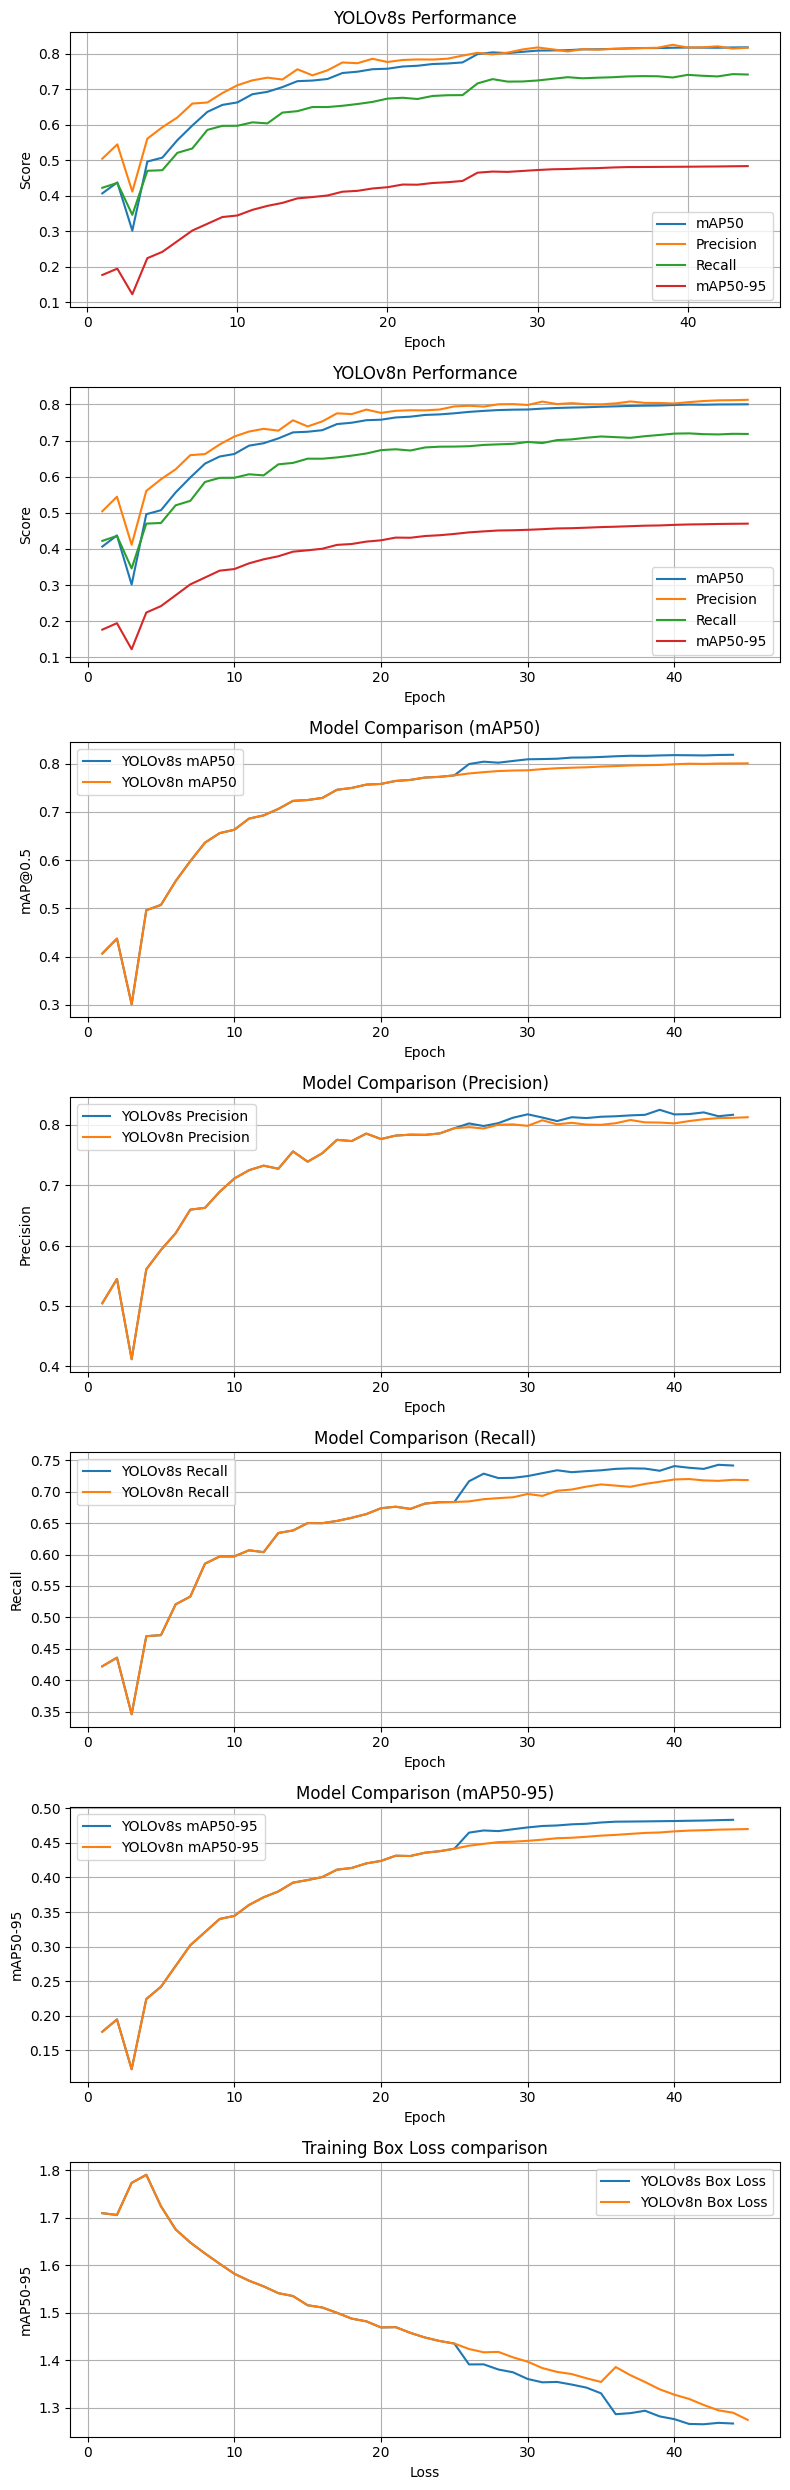

In [ ]:
# Model Metrics
import pandas as pd
import matplotlib.pyplot as plt

yolov8s_results = "/content/drive/MyDrive/Project/Model_Yolov8s/fire_v2/results.csv"
yolov8n_results = "/content/drive/MyDrive/Project/Model_Yolov8n/fire_v2/results.csv"
df_s = pd.read_csv(yolov8s_results)
df_n = pd.read_csv(yolov8n_results)

fig, axes = plt.subplots(7, 1, figsize=(8, 25))

# Yolov8n
axes[0].plot(df_s["epoch"], df_s["metrics/mAP50(B)"], label="mAP50")
axes[0].plot(df_s["epoch"], df_s["metrics/precision(B)"], label="Precision")
axes[0].plot(df_s["epoch"], df_s["metrics/recall(B)"], label="Recall")
axes[0].plot(df_s["epoch"], df_s["metrics/mAP50-95(B)"], label="mAP50-95")
axes[0].set_title("YOLOv8s Performance")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid()

# Yolov8s
axes[1].plot(df_n["epoch"], df_n["metrics/mAP50(B)"], label="mAP50")
axes[1].plot(df_n["epoch"], df_n["metrics/precision(B)"], label="Precision")
axes[1].plot(df_n["epoch"], df_n["metrics/recall(B)"], label="Recall")
axes[1].plot(df_n["epoch"], df_n["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1].set_title("YOLOv8n Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid()

# Comparison

# mAP50
axes[2].plot(df_s["epoch"], df_s["metrics/mAP50(B)"], label="YOLOv8s mAP50")
axes[2].plot(df_n["epoch"], df_n["metrics/mAP50(B)"], label="YOLOv8n mAP50")
axes[2].set_title("Model Comparison (mAP50)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("mAP@0.5")
axes[2].legend()
axes[2].grid()

# Precision
axes[3].plot(df_s["epoch"], df_s["metrics/precision(B)"], label="YOLOv8s Precision")
axes[3].plot(df_n["epoch"], df_n["metrics/precision(B)"], label="YOLOv8n Precision")
axes[3].set_title("Model Comparison (Precision)")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Precision")
axes[3].legend()
axes[3].grid()

# Recall
axes[4].plot(df_s["epoch"], df_s["metrics/recall(B)"], label="YOLOv8s Recall")
axes[4].plot(df_n["epoch"], df_n["metrics/recall(B)"], label="YOLOv8n Recall")
axes[4].set_title("Model Comparison (Recall)")
axes[4].set_xlabel("Epoch")
axes[4].set_ylabel("Recall")
axes[4].legend()
axes[4].grid()

#mAP50-95
axes[5].plot(df_s["epoch"], df_s["metrics/mAP50-95(B)"], label="YOLOv8s mAP50-95")
axes[5].plot(df_n["epoch"], df_n["metrics/mAP50-95(B)"], label="YOLOv8n mAP50-95")
axes[5].set_title("Model Comparison (mAP50-95)")
axes[5].set_xlabel("Epoch")
axes[5].set_ylabel("mAP50-95")
axes[5].legend()
axes[5].grid()

axes[6].plot(df_s["epoch"], df_s["train/box_loss"], label="YOLOv8s Box Loss")
axes[6].plot(df_n["epoch"], df_n["train/box_loss"], label="YOLOv8n Box Loss")
axes[6].set_title("Training Box Loss comparison")
axes[6].set_xlabel("Loss")
axes[6].set_ylabel("mAP50-95")
axes[6].legend()
axes[6].grid()



plt.tight_layout()
plt.show()


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_S3-N0878MF02008_jpg.rf.b0dbd09e58aab087ee4a5dc6c4275885.jpg: 736x736 1 fire, 20.1ms
Speed: 7.4ms preprocess, 20.1ms inference, 1.5ms postprocess per image at shape (1, 3, 736, 736)


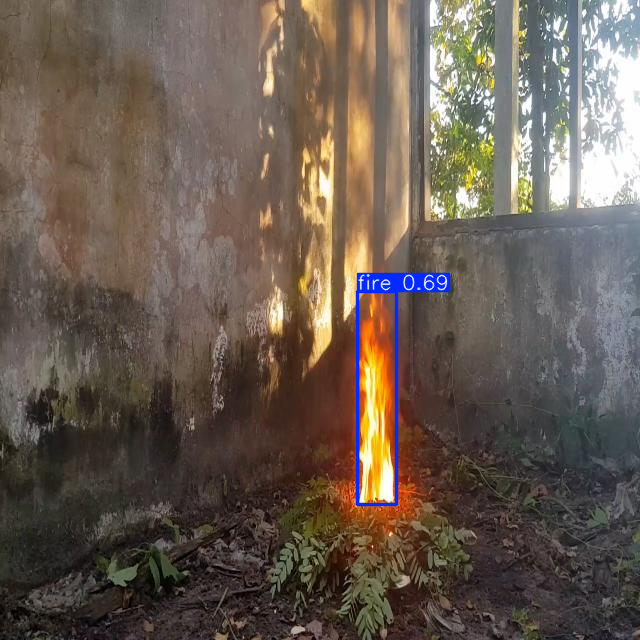


image 1/1 /content/dataset/Dataset_Merged/test/images/flame_bd9xu_smoll_271_jpg.rf.0b236cc81cbd9e3d4c798bae0baa4cbe.jpg: 416x736 1 fire, 19.1ms
Speed: 5.7ms preprocess, 19.1ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 736)


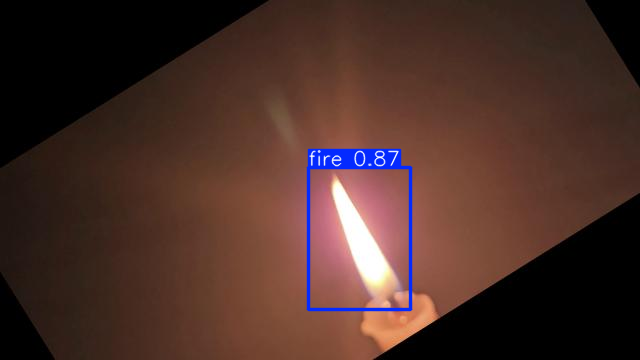


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_ck0kdgpnj8gvt0701oaod540q_jpeg_jpg.rf.94a2c4744184359482df5954b56c6aec.jpg: 736x736 1 smoke, 20.6ms
Speed: 5.0ms preprocess, 20.6ms inference, 1.6ms postprocess per image at shape (1, 3, 736, 736)


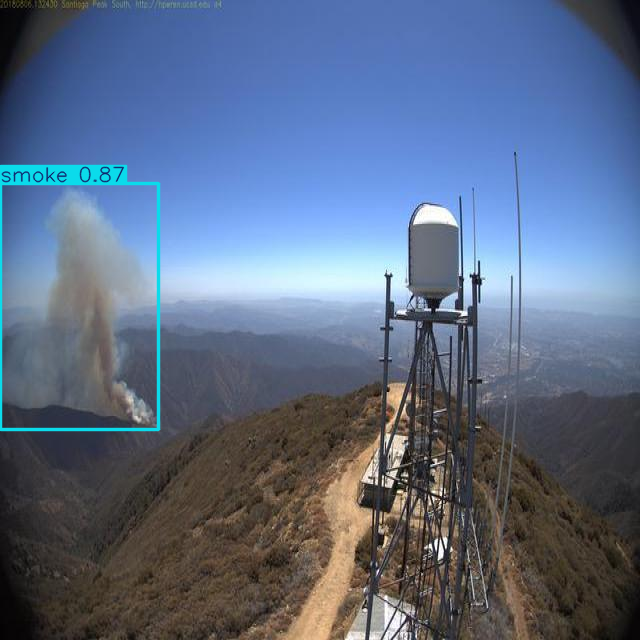


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_fire3_mp4-38_jpg.rf.208c7f785543ee91992968d801dfd53b.jpg: 736x416 1 fire, 15.3ms
Speed: 5.7ms preprocess, 15.3ms inference, 1.7ms postprocess per image at shape (1, 3, 736, 416)


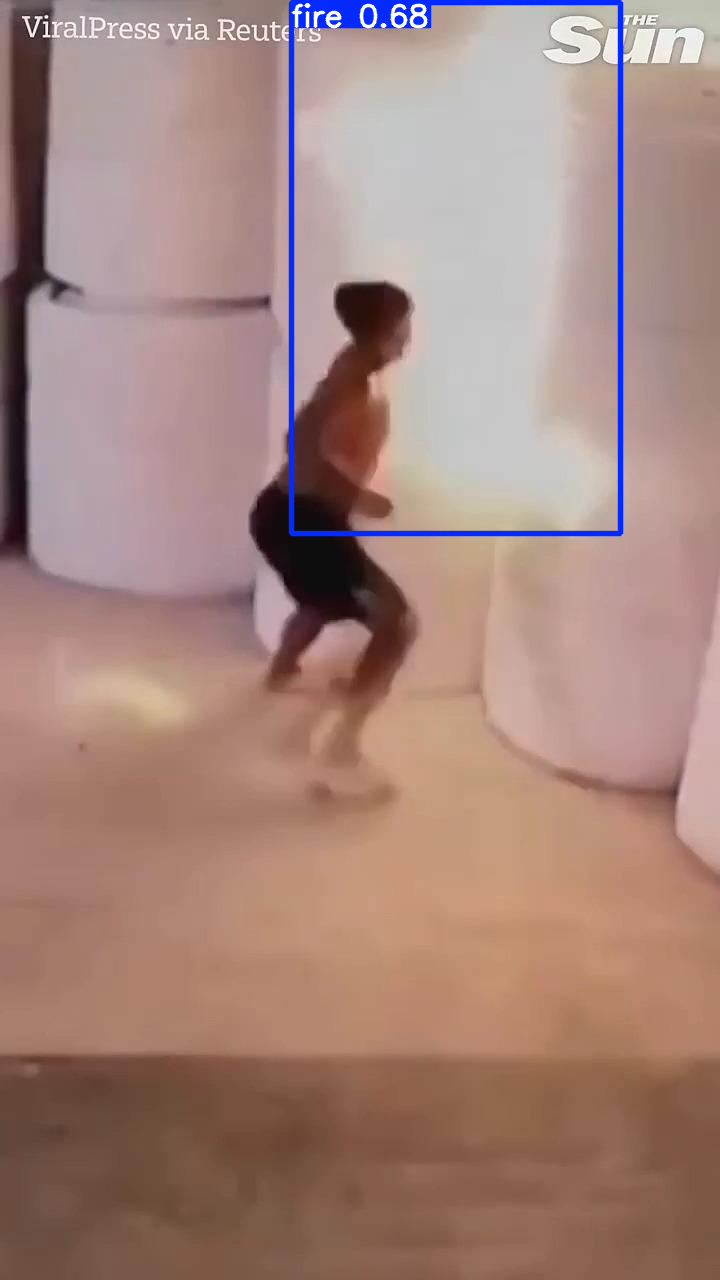


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_S3-N0878MF04124_jpg.rf.be4286628863f16f4c5280fb370938bc.jpg: 736x736 1 fire, 22.0ms
Speed: 7.0ms preprocess, 22.0ms inference, 3.7ms postprocess per image at shape (1, 3, 736, 736)


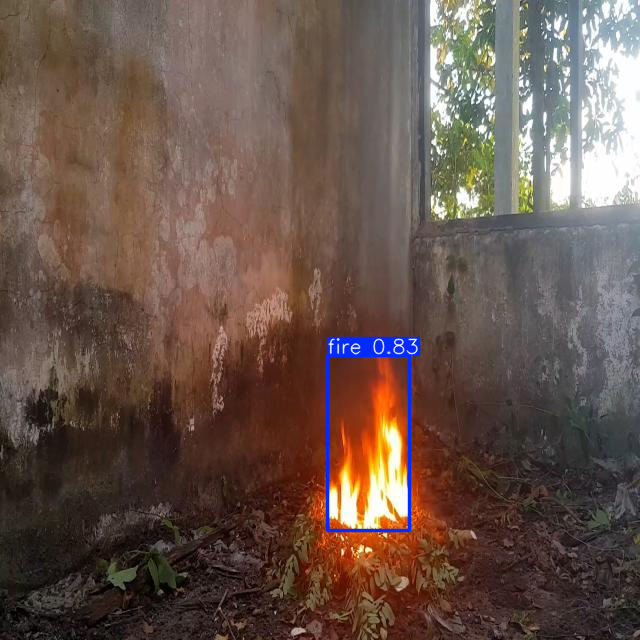


image 1/1 /content/dataset/Dataset_Merged/test/images/d_fire_WEB11784.jpg: 608x736 (no detections), 87.3ms
Speed: 5.7ms preprocess, 87.3ms inference, 0.9ms postprocess per image at shape (1, 3, 608, 736)


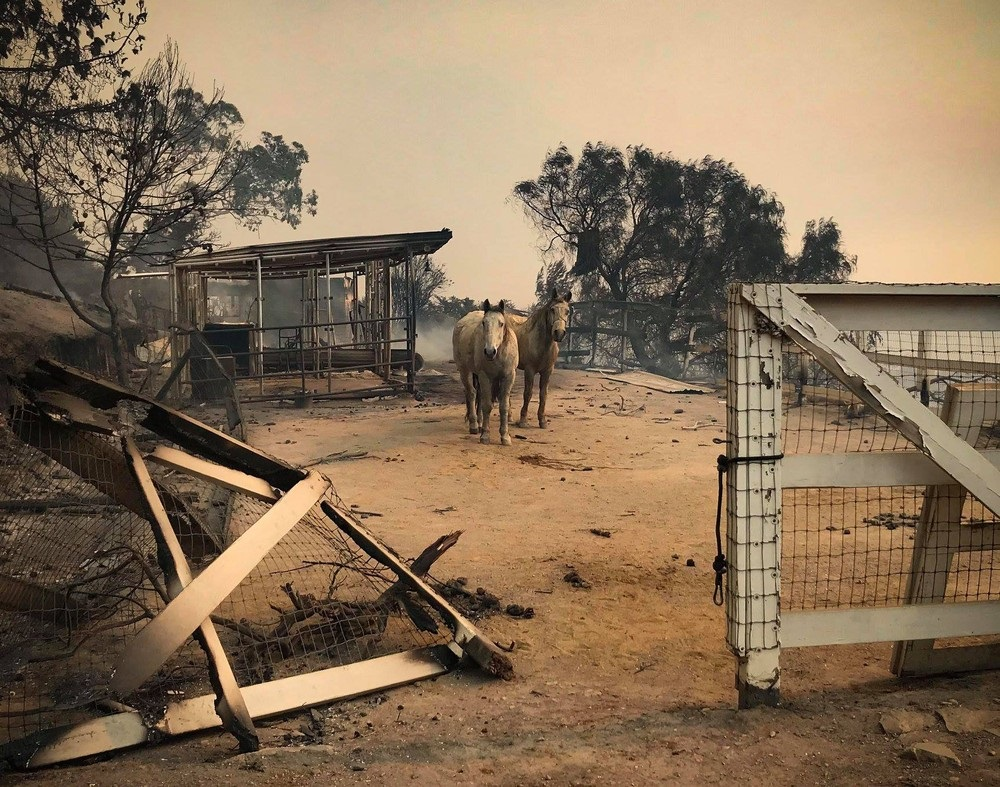


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_MirrorWEBFire1546_jpg.rf.261f630b8432c3a8119cf53039af17d6.jpg: 736x736 3 fires, 20.8ms
Speed: 6.4ms preprocess, 20.8ms inference, 3.7ms postprocess per image at shape (1, 3, 736, 736)


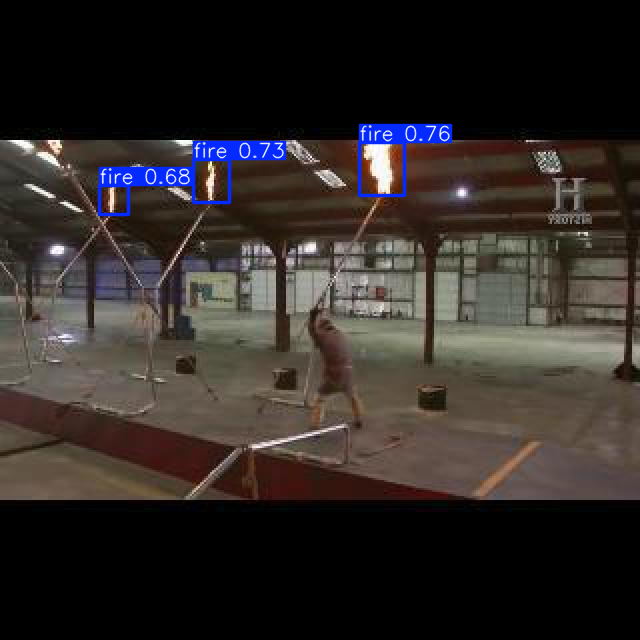


image 1/1 /content/dataset/Dataset_Merged/test/images/iron_wolf_yvovn_S3-N0925MF02163_jpg.rf.b53b707b842a2d48f7ec35f1abc9db7f.jpg: 736x736 1 fire, 19.6ms
Speed: 8.2ms preprocess, 19.6ms inference, 3.0ms postprocess per image at shape (1, 3, 736, 736)


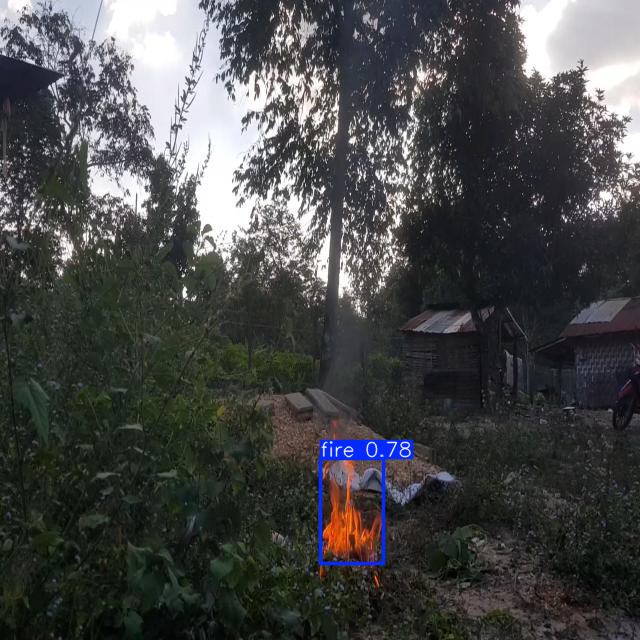


image 1/1 /content/dataset/Dataset_Merged/test/images/indoor_1699_jpg.rf.b5d8edf4cce03bd88bb8ad0ca0a824d0.jpg: 736x736 1 fire, 19.8ms
Speed: 8.8ms preprocess, 19.8ms inference, 2.9ms postprocess per image at shape (1, 3, 736, 736)


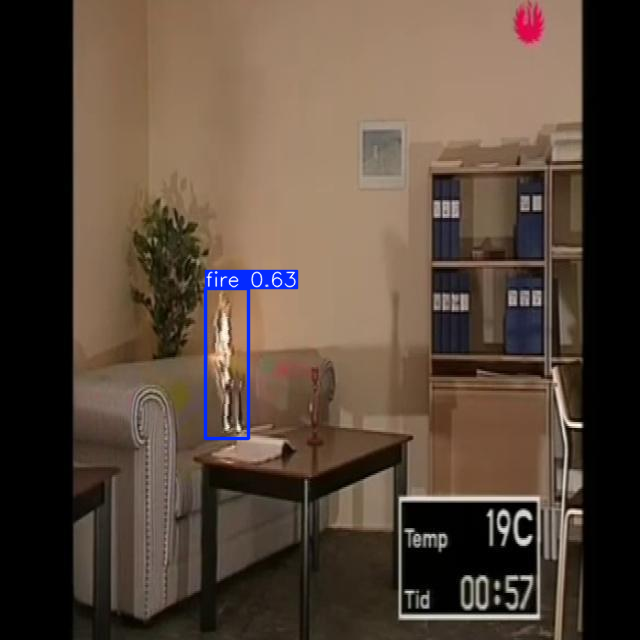


image 1/1 /content/dataset/Dataset_Merged/test/images/d_fire_WEB05255.jpg: 416x736 3 fires, 3 smokes, 17.4ms
Speed: 3.3ms preprocess, 17.4ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 736)


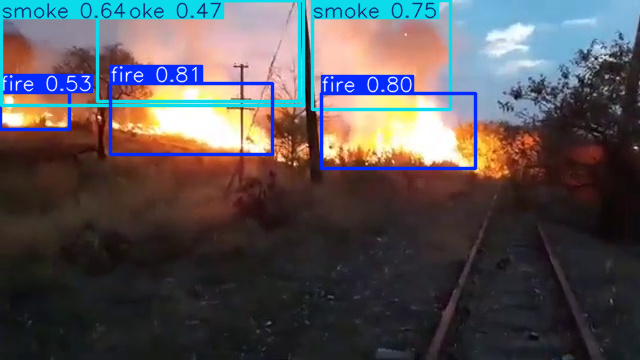

In [12]:
# Model Inferencing

model = YOLO("/content/drive/MyDrive/Project/Model_Yolov8s/fire_v2/weights/best.pt")

test_images = glob.glob("/content/dataset/Dataset_Merged/test/images/*.jpg")
sample = random.sample(test_images, 10)

for image_path in sample:
    results  = model.predict(image_path, conf=0.4)
    output_image = results[0].plot()
    output_image = Image.fromarray(output_image[..., ::-1])
    display(output_image)

In [2]:
# Model Inferencing on unseen data: Demo video; 50 sec

model = YOLO("/content/drive/MyDrive/Project/Model_Yolov8s/fire_v2/weights/best.pt")
results = model.predict(source="/content/drive/MyDrive/Project/Demo/fire_video.mp4",save=True,conf=0.25,
    show=False)

# Reference to video:


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1250) /content/drive/MyDrive/Project/Demo/fire_video.mp4: 576x736 (no detections), 67.0ms
video 1/1 (frame 2/1250) /content/drive/MyDrive/Project/Demo/fire_video.mp4: 576x736 (no detections), 16.7ms
video 1/1 (frame 3/1250) /content/drive/MyDrive/Project/Demo/fire_video.mp4: 576x736 (no detections), 16.7ms
video 1/1 (frame 4/1250) /content/drive/MyDrive/Project/Demo/fire_video.mp4: 576x736 (no detections), 16.6ms
video 1/1 (frame 5/125